# Proyecto #2: Clases y Objetos

### Integrantes: Sebastián Calvo Solano, Isaac Rodríguez Zuñiga

### Colegio Universitario de Cartago

### Programación 2

### Visualización

En este notebook se mostrarán los gráficos realizados en el proyecto gracias al dataset trabajado por lo cual primero se procederá con la carga de datos

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.eda import EDA

raiz_proyecto = Path(Path.cwd()).parent
sys.path.append(str(raiz_proyecto / "src"))

In [2]:
from src.eda import EDA
from src.visualizacion import Visualizador as vl
from src.ingesta import CargadorDatos as cd
from gestor.GestorPartidos import GestorPartidos


cargador = cd.CargadorDatos(
    url_source="https://raw.githubusercontent.com/martj42/international_results/master/results.csv",
    raw_path="data/raw",
    processed_path="data/processed"
)

df_para_eda = cargador.ejecutar()

gestor = GestorPartidos(df_para_eda)

df = vl.Visualizador(gestor)


INFO:src.ingesta.CargadorDatos:Descargando CSV desde https://raw.githubusercontent.com/martj42/international_results/master/results.csv
INFO:src.ingesta.CargadorDatos:Descarga completa, dimension de: 49509 filas y 9 columnas
INFO:src.ingesta.CargadorDatos:Filtro aplicado para 'FIFA World Cup': 1068 filas
INFO:src.ingesta.CargadorDatos:Guardado raw en: data\raw\raw_results.csv
INFO:src.ingesta.CargadorDatos:Guardado processed en: data\raw\partidos-mundial.csv


In [3]:
class Visualizador:
    def __init__(self, DF):
        self._DF = DF
        self._filas = self._DF.df.shape[0]
        self._columnas = self._DF.df.shape[1]

    @property
    def DF(self):
        return self._DF

    @property
    def columnas(self):
        return self._columnas

    @property
    def filas(self):
        return self._filas

Una vez creada la clase vamos a crearle las funciones con los gráficos

#### Mejores y Peores Diferencia de Goles

In [4]:
    # Gráfico de tornado (o mariposa) para ver la diferencia de gol
    def diferencia_goles(self):
        invocador = EDA.ProcesadorEDA(self._DF)
        tabla_goles = invocador.diferencia_goles().fillna(0)
        # Invocador sirve para llamar a la clase ProcesadorEDA

        top_negativo = tabla_goles.sort_values(by='Diferencia Goles', ascending=False).tail(5)
        top_positivo = tabla_goles.sort_values(by='Diferencia Goles', ascending=True).tail(5)
        # Se extrae en ambos tail para una mejor representación en el gráfico

        df_tornado = pd.concat([top_negativo, top_positivo]).reset_index(drop=True)
        # Se invierte el orden gracias al "reset_index" para que vaya del puesto 1 al puesto 5

        fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
        y_pos = np.arange(len(df_tornado))
        colores = ['#E74C3C' if x < 0 else '#48A111' for x in df_tornado['Diferencia Goles']]
        barras = ax.barh(y_pos, df_tornado['Diferencia Goles'], color= colores)
        # Posicionamos los 10 países en el lienzo y le damos colores

        ax.axvline(0, color='black', linewidth=1.5, linestyle='-')
        # Línea que divide las barras

        for barra in barras:
            width = barra.get_width()
            if width < 0:
                ax.text(width - 4, barra.get_y() + barra.get_height() / 2, f'{int(width)}',
                        va='center', ha='right', color='black', fontweight='bold')
            else:
                ax.text(width + 4, barra.get_y() + barra.get_height() / 2, f'+{int(width)}',
                        va='center', ha='left', color='black', fontweight='bold')
        # Aquí se asignan etiquetas de los ejes

        ax.set_title('Las 5 Selecciones con Mejores y Peores Diferencias de Goles',
                     fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Diferencia de Goles')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_tornado['Selección'], fontsize=10, fontweight='bold')
        # Nombre de las selecciones en el eje y

        limite_max = max(abs(df_tornado['Diferencia Goles'].min()), abs(df_tornado['Diferencia Goles'].max())) + 25
        ax.set_xlim(-limite_max, limite_max)
        # Límite de simetría en los ejes x

        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(left=False)

        return plt.show()

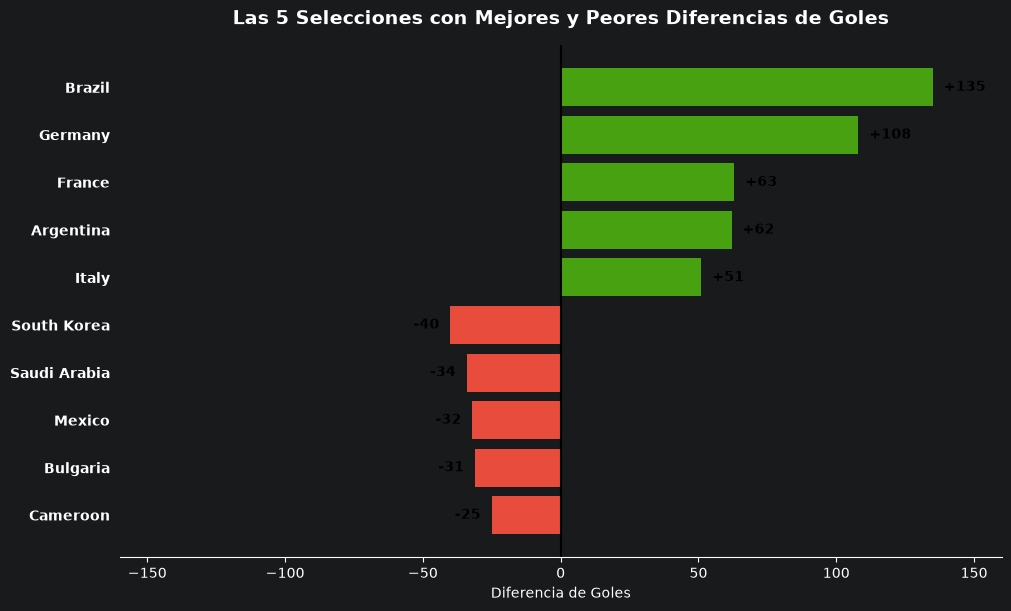

In [5]:
df.grafico_diferencia_goles()

La diferencia de gol es la resta entre los goles anotados y los goles recibidos, entre mayor sea esta significa que marca mas goles que los que recibe, esto viéndose reflejado en Brasil y Alemania que como se observo en el notebook "01_EDA" estas eran las selecciones con mas goles marcados pero observamos que Alemania a recibido mas goles que Brasil siendo este el factor clave para que Brasil esté de primera.

Por otro lado si se reciben mas goles que los que se anotan entonces esta va a terminar en negativa, vemos como Corea del Sur lidera con -40  en cuanto a diferencia de gol, siendo esta la selección con peor diferencia de gol en la historia de lo mundiales.

#### Cantidad de Goles en Cada Mundial

In [6]:
    # Línea del tiempo que muestra los goles marcados en cada edición del mundial
    def goles_por_mundial(self):
        invocador = EDA.ProcesadorEDA(self._DF)
        goles_mundiales = invocador.mas_gol_mundial().sort_values(by = 'Año', ascending = True)

        valores_x = goles_mundiales['Año']
        valores_y = goles_mundiales['Goles Anotados']
        # Se obtienen los valores del eje x y del eje y

        fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
        ax.plot(valores_x, valores_y, color="#48A111", marker='o', linewidth=2, markersize=6)

        ax.set_title('Goles Marcados en los Mundiales', fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('Cantidad de Goles', fontsize=11)
        ax.set_xlabel('Edición del Mundial (Año)', fontsize=11)
        # Título del gráfico y etiquetas de los ejes

        for x, y in zip(valores_x, valores_y):
            ax.text(
                x,
                y + 4,
                f'{int(y)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='#2C3E50'
            )
        # Línea creada para poner la cantidad exacta de goles anotados

        ax.set_xticks(valores_x)
        plt.xticks(rotation=45)
        # Se inserta en el gráfico los años en el eje x y se rota el nombre para mejor legibilidad

        ax.set_ylim(min(valores_y) - 10, max(valores_y) + 20)
        # Se amplía el rango de límite de altura

        ax.grid(True, linestyle='--', alpha=0.5)
        return plt.show()

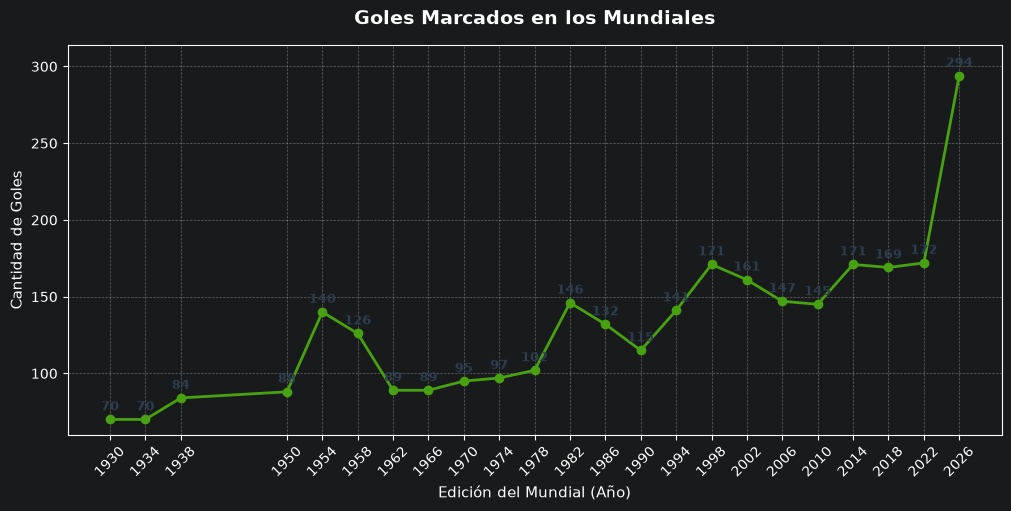

In [7]:
df.goles_por_mundial()

Esta línea del tiempo nos muestra el total de goles anotados en los mundiales disputados desde sus primera edición en 1930, observamos que desde 1939 hasta 1950 no se disputaron mundiales (esto debido al contexto histórico de la época) y como conforme avanzan las ediciones estos han empezado a poseer mas y mas goles, debido a cambios que ha sufrido el torneo o cambios que ha sufrido el deporte como tal a lo largo del tiempo.

#### Top 5 Histórico

In [8]:
    # Gráfico de telaraña con las mejores selecciones en mundiales históricamente
    def mejores_cinco_selecciones(self):
        invocador = EDA.ProcesadorEDA(self._DF)
        ranking_completo = invocador.ranking_mundial()
        top5 = ranking_completo.head(5).copy()

        columnas_radar = ['Cantidad de Victorias', 'Cantidad de Empates', 'Cantidad de Derrotas','Goles Anotados','Goles Recibidos', 'Diferencia Goles','Puntos']
        categorias = ['Victorias', 'Empates', 'Derrotas','Gol Anotado','Gol Recibido', 'Dif. Goles','Puntos']
        # Recibe el nombre de las columnas y se les asigna un nombre mas corto

        num_variables = len(categorias)

        angulos = np.linspace(0, 2 * np.pi, num_variables, endpoint=False).tolist()
        # Se calculan los ángulos de cada eje en círculo

        angulos += angulos[:1]

        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), layout='constrained')
        ax.set_xticks(angulos[:-1])
        ax.set_xticklabels(categorias, fontsize=11, fontweight='bold')
        colores = ['#FFBF00', '#F62440', '#9CD5FF', '#2CA02C', '#1B4EF5']
        # Mostrar el nombre de las selecciones y asignarles un color a cada una

        for i, (idx, fila) in enumerate(top5.iterrows()):
            pais = fila['Selección']
            puntos_pais = fila['Puntos']

            # Extraemos los valores de las columnas seleccionadas para el país actual
            valores = fila[columnas_radar].values.tolist()

            valores += valores[:1]
            # Se cierrra el bucle duplicando el valor

            ax.plot(angulos, valores, color=colores[i], linewidth=2, label=f"{pais} ({puntos_pais} pts)")
            # Rellenamos el área con un color translúcido (alpha) para que se solapen elegantemente
            ax.fill(angulos, valores, color=colores[i], alpha=0.15)
            # Se dibuja la línea del país

        ax.set_title('Top 5 Histórico de los Mundiales', fontsize=14, fontweight='bold', pad=20)
        ax.legend(title = 'Puntos Totales',loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10, shadow=True)
        # Título del gráfico y leyenda que muestra el nombre del país y los puntos totales

        ax.grid(color='#AAAAAA', linestyle='--', linewidth=0.5)
        # Estilo de las líneas de la telaraña

        return plt.show()


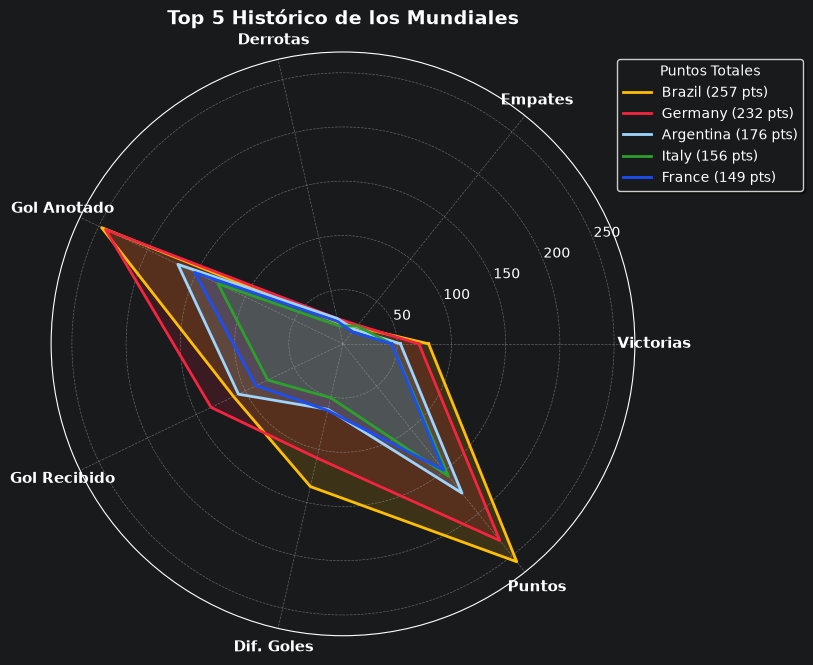

In [9]:
df.mejores_cinco_selecciones()

La tabla de los puntajes funciona como en el deporte mismo:
- Victoria: 3 puntos
- Empate: 1 punto
- Derrota: 0 puntos

Esto es importante saberlo porque vemos como Francia a pesar de tener mas victorias que Italia esta está por debajo, debido a que Italia posee mas empates que esta, además tenemos una comparativa de otras estadísticas de estas selecciones a lo largo de los mundiales, selecciones que han sido al menos 2 veces campeonas mundiales.

#### Comparativa entre Sedes Campeonas y Sedes No Campeonas

In [10]:
    # Sedes campeonas vs campeones no sedes
    def campeon_sede_otro(self):
        invocador = EDA.ProcesadorEDA(self._DF)
        sedes_campeones = invocador.veces_sede()

        coincide_sede = 0
        otro_campeon = 0
        # Varaibles que van a llevar el conteo de las selecciones campeonas

        for _, fila in sedes_campeones.iterrows():
            sede = fila['País Sede']
            campeones_texto = fila['Campeón(es) Coronado(s)']

            if not campeones_texto or campeones_texto == "" or campeones_texto == "Por Definir":
                continue

            lista_campeones = [c.strip() for c in campeones_texto.split(',')]
            # Los campeones se registran en una lista para en caso de haber agrupaciones

            if sede in lista_campeones:
                coincide_sede += 1
                if len(lista_campeones) > 1:
                    otro_campeon += (len(lista_campeones) - 1)
            else:
                otro_campeon += len(lista_campeones)

        categorias = ['Otro País', 'País Sede']
        totales = [otro_campeon, coincide_sede]
        colores = ['#48A111', '#E74C3C']
        # Preparación de datos para el gráfico

        fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')
        barras = ax.bar(categorias, totales, color=colores, width=0.5, edgecolor='#2C3E50', linewidth=1)

        for barra in barras:
            alto = barra.get_height()
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                alto + 0.3,
                f'{int(alto)}',
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold',
                color='#2C3E50'
            )
        # Esto añade las cantidades de campeones por encima de las barras

        ax.set_title('Sedes Campeonas vs No Sedes Campeonas', fontsize=13, fontweight='bold', pad=15)
        ax.set_ylabel('Cantidad de Ediciones', fontsize=11)

        ax.set_ylim(0, max(totales) + 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

        return plt.show()

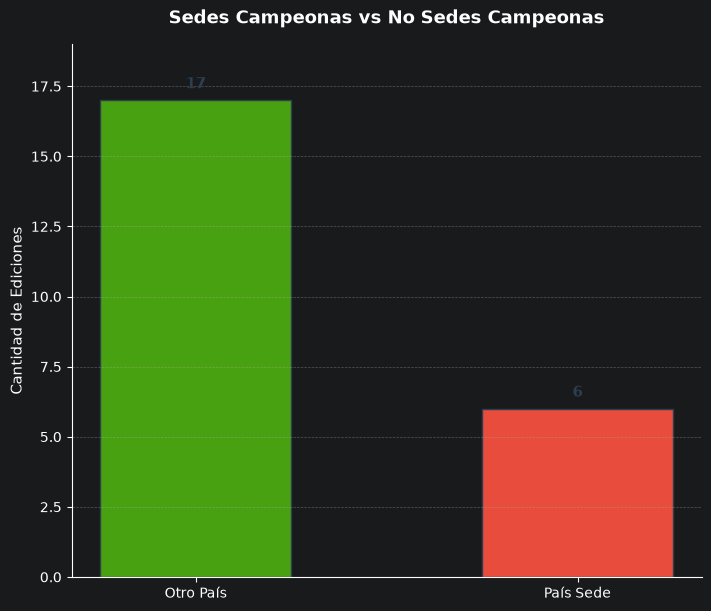

In [11]:
df.campeon_sede_otro()

Este gráfico nos dice la cantida de veces que un país ha sido campeón siendo este la sede o no, observamos que la diferencia es considerable entre uno y otro, siendo los países no sede los que normalmente ganan el torneo.

#### Mayor Subcampeonatos

In [12]:
    # Países con mas subcampeonatos
    def subcampeones(self):
        invocador = EDA.ProcesadorEDA(self._DF)
        sede = invocador.df

        sede['Año'] = sede['date'].dt.year
        indices_finales = sede.groupby('Año')['date'].idxmax()
        finales = sede.loc[indices_finales].copy()
        finales = finales[finales['Año'] != 2026]
        # Se almacenan las finales de los años excepto 2026 que aún no transcurre

        def obtener_subcampeon(fila):
            if fila['home_score'] > fila['away_score']:
                return fila['away_team']
            else:
                return fila['home_team']
        finales['Subcampeón'] = finales.apply(obtener_subcampeon, axis=1)
        # Se obtienen y almacenan los subcampeones

        conteo_subcampeones = finales['Subcampeón'].value_counts().reset_index()
        conteo_subcampeones.columns = ['Selección', 'Veces Subcampeón']
        conteo_subcampeones = conteo_subcampeones.sort_values(by='Veces Subcampeón', ascending=True)
        # Cuenta las veces que la selección aparece como subcampeona y lo ordena de mas a menos apariciones

        valores_x = conteo_subcampeones['Veces Subcampeón']
        valores_y = conteo_subcampeones['Selección']

        fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
        barras = ax.barh(valores_y, valores_x, color='#95A5A6', edgecolor='#7F8C8D', height=0.6)
        # Color que se asemeja a la plata

        ax.set_title('Selecciones con Más Subcampeonatos en la Historia de los Mundiales', fontsize=14,
                     fontweight='bold', pad=15)
        ax.set_xlabel('Cantidad de Veces Subcampeón', fontsize=11)
        ax.set_ylabel('Selección', fontsize=11)

        ax.set_xticks(range(0, int(max(valores_x)) + 2))
        # Solo muestra números enteros

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.3)

        return plt.show()

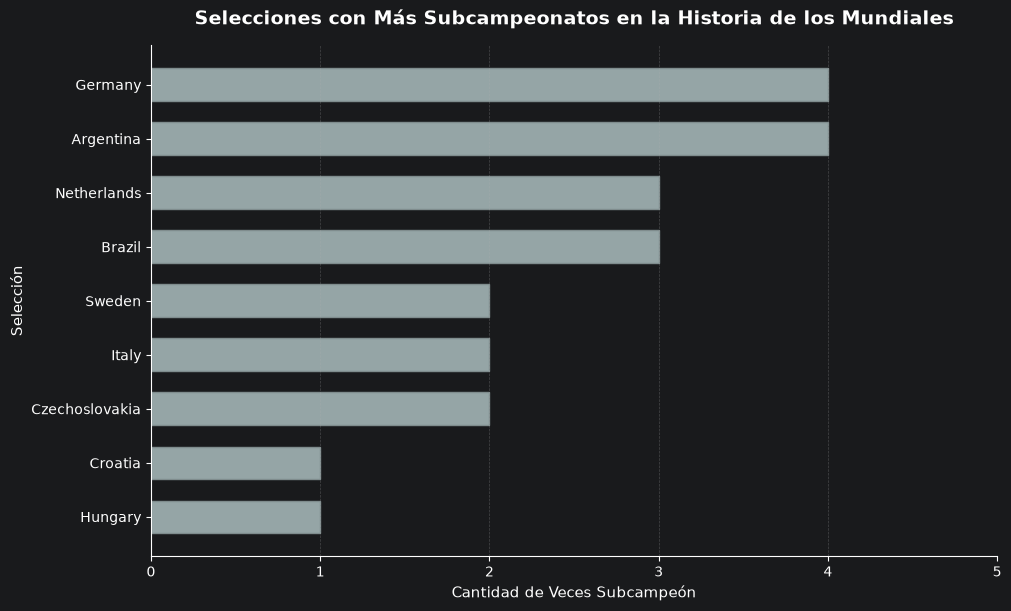

In [13]:
df.subcampeones()

Al ser subcampeonatos se escogió un color gris que represente la medalla de plata que normalmente se dán en competiciones al quedar segundos, esta estádistica es interesante ya que nos dice cuales son los países que mas oscilan el quedar entre los puestos mas altos en los mundiales, siendo Holanda una selección que ha llegado a 3 finales del mundo pero nunca ganado alguna.